# Examine pretrained word embeddings for "toxic" in COCA and ACL

This notebook looks at sampled tokens of the word toxic in both COCA and ACL and sees how they cluster in embedding space.

The main questions are:
1. Do the observed clusters correspond to differences in frame semantic emphasis of the word?
1. Do some senses (as represented by clusters) have more overlap between both sources?

Hypothesis 1:

When split into five senses, COCA 1 (predicative adjective metaphorical---person is toxic) and COCA 3 (AN metaphorical---toxic person, toxic situation) will align with ACL 2 ()

Hypothesis 2: Sense 2 (toxic as presupposed) emerges over time. 

- find a dataset of presupposition 


These hypotheses require us to measure the semantics and necessitate recording annotator judgments as well as the employment of automated methods for semantic analysis. 

Hypothesis 1: Metaphorical senses of toxic focus on the toxic substance/agent.


## 0. Preamble

In [61]:
import pandas as pd
import numpy as np
from minicons import cwe 
import torch
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import umap
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

## 1. Load Data

In [62]:
# load tokens

# acl
acl = pd.read_csv('/home/gsc685/data/collected_tokens/acl/toxic.csv')
acl['source'] = 'acl'

# coca
coca = pd.read_csv('/home/gsc685/data/collected_tokens/coca/toxic.csv')
coca['source'] = 'coca'


df = pd.concat([acl, coca], ignore_index=True)
print(f"Total tokens: {len(df)}")
print(f"ACL tokens: {len(acl)}")
print(f"COCA tokens: {len(coca)}")

Total tokens: 5435
ACL tokens: 4298
COCA tokens: 1137


In [63]:
# change the first column to token_id
df = df.rename(columns={df.columns[0]: 'token_id'})

## 2. Embeddings

Load roberta-base and get embeddings from layer 7 for each token of 'toxic' in the dataset. Use the minicons library to get word embeddings. Use the start_idx and end_idx columns. 


In [64]:
# Prepare data in the format required by extract_representation()
# Format: [(sentence, (start_char, end_char)), ...]
# Convert word indices to character indices

data = []
for idx, row in df.iterrows():
    sentence = row['text'] if 'text' in df.columns else row['sentence']
    data.append((sentence, 'toxic'))

print(f"Prepared {len(data)} instances for embedding extraction")
print(f"Examples: {data[:2]}")



Prepared 5435 instances for embedding extraction
Examples: [('We then expanded the coverage to less well known human diseases, zoonotic diseases, animal diseases and diseases caused by toxic substances such as sarin, hydrogen sulfide, sulfur dioxide and ethylene.', 'toxic'), ('2021 ), using large language models for data augmentation presents several challenges: they exhibit social biases and are prone to generating toxic content.', 'toxic')]


In [65]:
data[:5]

[('We then expanded the coverage to less well known human diseases, zoonotic diseases, animal diseases and diseases caused by toxic substances such as sarin, hydrogen sulfide, sulfur dioxide and ethylene.',
  'toxic'),
 ('2021 ), using large language models for data augmentation presents several challenges: they exhibit social biases and are prone to generating toxic content.',
  'toxic'),
 ('2021) detect toxic language in a user utterance, they stop producing output (Xu et al.,',
  'toxic'),
 ("After spawning, the fish die in their thousands -delivering their toxic cargo to the lake sediment and increasing its PCB content by more than sevenfold when the density of returning salmon is high.' (",
  'toxic'),
 ('The identification of fertile translations is useful because (i) they frequentlty correspond to non-canonical translations, e.g. paraphrastic variants and (ii) they tend to correspond to vulgarized forms of technical terms (e.g. « cytotoxic » vs. « toxic to the cells ») which are

In [66]:
# Load RoBERTa-base model
model = cwe.CWE('roberta-base', device='cuda' if torch.cuda.is_available() else 'cpu')

print(f"Model loaded on: {model.device}")
print(f"Model: roberta-base")

Model loaded on: cuda
Model: roberta-base


In [67]:
# Extract embeddings from layer 7 using extract_representation()
# Process in batches to handle long sequences and collect results

embeddings_list = []
batch_size = 32

print("Extracting embeddings...")
for i in tqdm(range(0, len(data), batch_size)):
    batch = data[i:i+batch_size]
    try:
        batch_embeddings = model.extract_representation(batch, layer=7)
        embeddings_list.extend([emb.cpu().numpy() for emb in batch_embeddings])
    except Exception as e:
        print(f"Error in batch {i//batch_size}: {e}")
        # Process individually to identify problematic examples
        for j, item in enumerate(batch):
            try:
                emb = model.extract_representation([item], layer=7)
                embeddings_list.append(emb[0].cpu().numpy())
            except Exception as e2:
                print(f"  Failed at index {i+j}: {e2}")
                # Add a zero vector as placeholder
                embeddings_list.append(np.zeros(768))

# Add embeddings to dataframe
df['embedding'] = embeddings_list

print(f"\nEmbedding extraction complete!")
print(f"Total embeddings: {len(embeddings_list)}")
print(f"Embedding dimension: {embeddings_list[0].shape}")

Extracting embeddings...


  0%|          | 0/170 [00:00<?, ?it/s]

Error in batch 0: list index out of range
  Failed at index 7: list index out of range
  Failed at index 8: list index out of range
  Failed at index 9: list index out of range
  Failed at index 10: list index out of range
  Failed at index 18: list index out of range


  1%|          | 1/170 [00:00<01:12,  2.33it/s]

Error in batch 1: list index out of range
  Failed at index 41: list index out of range
  Failed at index 42: list index out of range
  Failed at index 43: list index out of range
  Failed at index 54: list index out of range


...

Error in batch 165: list index out of range
  Failed at index 5280: list index out of range


 98%|█████████▊| 166/170 [00:40<00:00,  5.26it/s]

Error in batch 167: list index out of range


100%|██████████| 170/170 [00:41<00:00,  4.15it/s]

  Failed at index 5369: list index out of range

Embedding extraction complete!
Total embeddings: 5435
Embedding dimension: (768,)


In [68]:
# Remove rows with empty (zero) embeddings
def is_zero_embedding(emb):
    return np.allclose(emb, 0)

zero_mask = df['embedding'].apply(is_zero_embedding)
n_zero = zero_mask.sum()

print(f"Rows with zero embeddings: {n_zero}")
df = df[~zero_mask].reset_index(drop=True)
print(f"Remaining rows after filtering: {len(df)}")

Rows with zero embeddings: 265
Remaining rows after filtering: 5170


## 3. K-Means Clustering - separate sources

In [69]:
# Separate data by source
df_acl = df[df['source'] == 'acl'].copy()
df_coca = df[df['source'] == 'coca'].copy()

# Convert embeddings to arrays
X_acl = np.stack(df_acl['embedding'].values)
X_coca = np.stack(df_coca['embedding'].values)

print(f"ACL embeddings shape: {X_acl.shape}")
print(f"COCA embeddings shape: {X_coca.shape}")

ACL embeddings shape: (4056, 768)
COCA embeddings shape: (1114, 768)


In [70]:
# Find optimal number of clusters using silhouette score, Calinski-Harabasz index, and elbow method
def find_optimal_clusters(X, source_name, k_range=range(2, 16)):
    """Run k-means for different k values and return clustering metrics."""
    silhouette_scores = []
    calinski_harabasz_scores = []
    inertias = []
    
    for k in tqdm(k_range, desc=f"Clustering {source_name}"):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        silhouette_scores.append(silhouette_score(X, labels))
        calinski_harabasz_scores.append(calinski_harabasz_score(X, labels))
        inertias.append(kmeans.inertia_)
    
    return list(k_range), silhouette_scores, calinski_harabasz_scores, inertias

# Run for ACL
k_values_acl, sil_acl, ch_acl, inertia_acl = find_optimal_clusters(X_acl, "ACL")

# Run for COCA
k_values_coca, sil_coca, ch_coca, inertia_coca = find_optimal_clusters(X_coca, "COCA")

Clustering COCA: 100%|██████████| 14/14 [00:22<00:00,  1.58s/it]


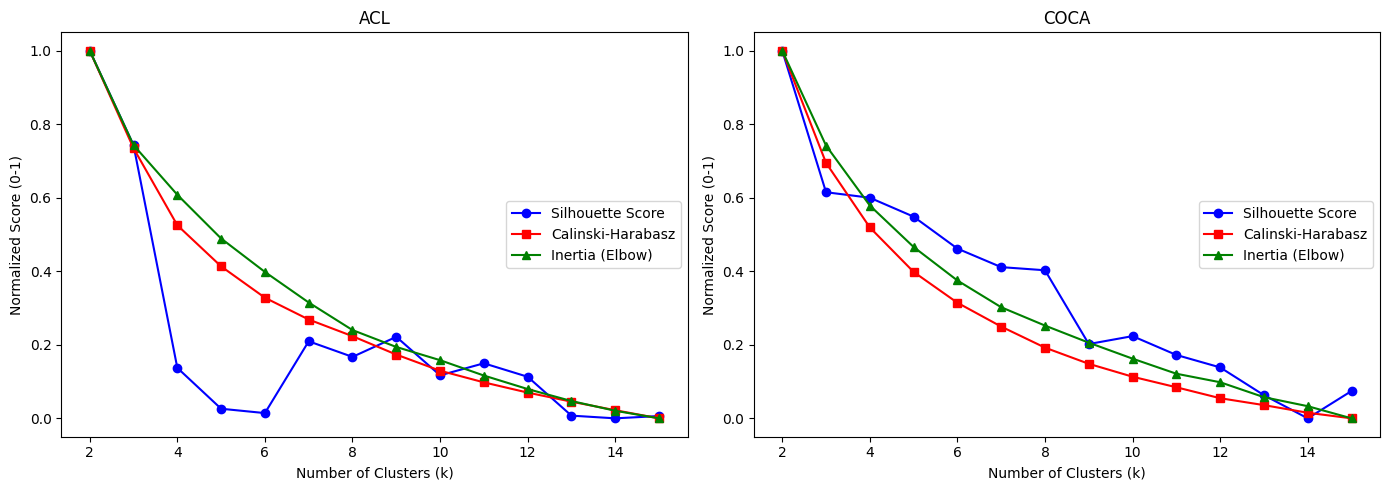


ACL:
  Silhouette: Best k = 2, Score = 0.1060
  Calinski-Harabasz: Best k = 2, Score = 499.47

COCA:
  Silhouette: Best k = 2, Score = 0.1114
  Calinski-Harabasz: Best k = 2, Score = 132.70


In [71]:
# Plot all three metrics - each with its own y-scale (normalized to 0-1)
def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACL
ax1 = axes[0]
ax1.plot(k_values_acl, normalize(sil_acl), 'b-o', label='Silhouette Score')
ax1.plot(k_values_acl, normalize(ch_acl), 'r-s', label='Calinski-Harabasz')
ax1.plot(k_values_acl, normalize(inertia_acl), 'g-^', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Normalized Score (0-1)')
ax1.set_title('ACL')
ax1.legend(loc='center right')

# COCA
ax2 = axes[1]
ax2.plot(k_values_coca, normalize(sil_coca), 'b-o', label='Silhouette Score')
ax2.plot(k_values_coca, normalize(ch_coca), 'r-s', label='Calinski-Harabasz')
ax2.plot(k_values_coca, normalize(inertia_coca), 'g-^', label='Inertia (Elbow)')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Normalized Score (0-1)')
ax2.set_title('COCA')
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

# Report best k for each metric
best_k_sil_acl = k_values_acl[np.argmax(sil_acl)]
best_k_ch_acl = k_values_acl[np.argmax(ch_acl)]
best_k_sil_coca = k_values_coca[np.argmax(sil_coca)]
best_k_ch_coca = k_values_coca[np.argmax(ch_coca)]

print(f"\nACL:")
print(f"  Silhouette: Best k = {best_k_sil_acl}, Score = {max(sil_acl):.4f}")
print(f"  Calinski-Harabasz: Best k = {best_k_ch_acl}, Score = {max(ch_acl):.2f}")
print(f"\nCOCA:")
print(f"  Silhouette: Best k = {best_k_sil_coca}, Score = {max(sil_coca):.4f}")
print(f"  Calinski-Harabasz: Best k = {best_k_ch_coca}, Score = {max(ch_coca):.2f}")

In [72]:
# Fit final k-means models using Calinski-Harabasz optimal k

# we want to use 8 here, where sillhouette score peaks for both datasets
best_k = 8

kmeans_acl = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_acl['cluster'] = kmeans_acl.fit_predict(X_acl)

kmeans_coca = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_coca['cluster'] = kmeans_coca.fit_predict(X_coca)

print(f"ACL cluster distribution (k={best_k_ch_acl}):")
print(df_acl['cluster'].value_counts().sort_index())
print(f"\nCOCA cluster distribution (k={best_k_ch_coca}):")
print(df_coca['cluster'].value_counts().sort_index())

ACL cluster distribution (k=2):
cluster
0    774
1    541
2    367
3    391
4    646
5    544
6    325
7    468
Name: count, dtype: int64

COCA cluster distribution (k=2):
cluster
0     56
1    150
2    149
3    129
4    151
5     86
6    209
7    184
Name: count, dtype: int64


## 4. Cluster Matching

Match clusters from ACL to clusters from COCA based on centroid similarity.

In [73]:
# Get cluster centroids from the fitted models
acl_centroids = kmeans_acl.cluster_centers_
coca_centroids = kmeans_coca.cluster_centers_

print(f"ACL centroids shape: {acl_centroids.shape}")
print(f"COCA centroids shape: {coca_centroids.shape}")

ACL centroids shape: (8, 768)
COCA centroids shape: (8, 768)


In [74]:
# Compute cosine similarity between all ACL and COCA centroids
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(acl_centroids, coca_centroids)

print(f"Similarity matrix shape: {similarity_matrix.shape}")
print(f"(rows = ACL clusters, cols = COCA clusters)")

Similarity matrix shape: (8, 8)
(rows = ACL clusters, cols = COCA clusters)


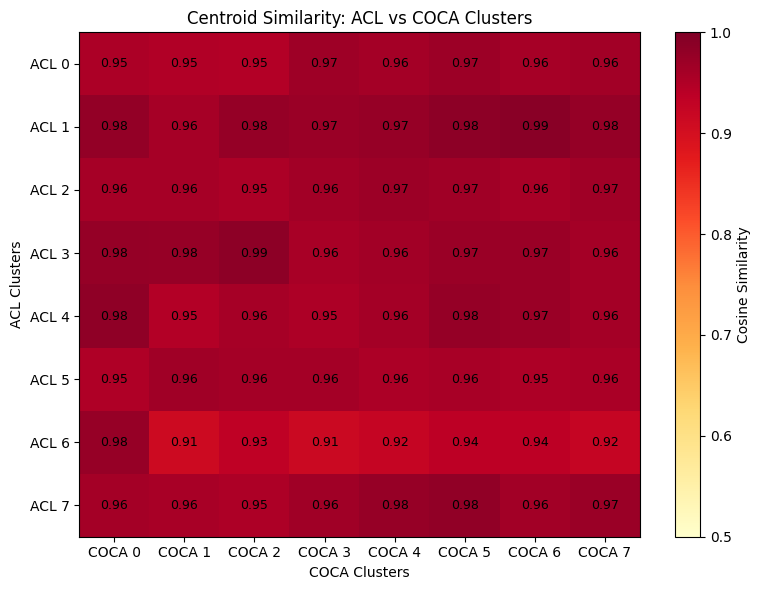

In [75]:
# Visualize the similarity matrix as a heatmap
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(similarity_matrix, cmap='YlOrRd', aspect='auto', vmin=0.5, vmax=1.0)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Cosine Similarity')

# Labels
ax.set_xticks(range(similarity_matrix.shape[1]))
ax.set_yticks(range(similarity_matrix.shape[0]))
ax.set_xticklabels([f'COCA {i}' for i in range(similarity_matrix.shape[1])])
ax.set_yticklabels([f'ACL {i}' for i in range(similarity_matrix.shape[0])])
ax.set_xlabel('COCA Clusters')
ax.set_ylabel('ACL Clusters')
ax.set_title('Centroid Similarity: ACL vs COCA Clusters')

# Add text annotations
for i in range(similarity_matrix.shape[0]):
    for j in range(similarity_matrix.shape[1]):
        text = ax.text(j, i, f'{similarity_matrix[i, j]:.2f}',
                       ha='center', va='center', color='black', fontsize=9)

plt.tight_layout()
plt.show()

In [76]:
# Find best matches: for each ACL cluster, find the most similar COCA cluster
acl_labels = kmeans_acl.labels_
coca_labels = kmeans_coca.labels_

print("Best matches (ACL -> COCA):")
print("-" * 50)
for acl_cluster in range(similarity_matrix.shape[0]):
    best_coca = np.argmax(similarity_matrix[acl_cluster])
    best_sim = similarity_matrix[acl_cluster, best_coca]
    acl_size = (acl_labels == acl_cluster).sum()
    coca_size = (coca_labels == best_coca).sum()
    print(f"ACL {acl_cluster} (n={acl_size}) -> COCA {best_coca} (n={coca_size}) | similarity: {best_sim:.3f}")

print("\n" + "=" * 50 + "\n")

# Find best matches: for each COCA cluster, find the most similar ACL cluster
print("Best matches (COCA -> ACL):")
print("-" * 50)
for coca_cluster in range(similarity_matrix.shape[1]):
    best_acl = np.argmax(similarity_matrix[:, coca_cluster])
    best_sim = similarity_matrix[best_acl, coca_cluster]
    coca_size = (coca_labels == coca_cluster).sum()
    acl_size = (acl_labels == best_acl).sum()
    print(f"COCA {coca_cluster} (n={coca_size}) -> ACL {best_acl} (n={acl_size}) | similarity: {best_sim:.3f}")

Best matches (ACL -> COCA):
--------------------------------------------------
ACL 0 (n=774) -> COCA 5 (n=86) | similarity: 0.969
ACL 1 (n=541) -> COCA 6 (n=209) | similarity: 0.990
ACL 2 (n=367) -> COCA 4 (n=151) | similarity: 0.970
ACL 3 (n=391) -> COCA 2 (n=149) | similarity: 0.985
ACL 4 (n=646) -> COCA 0 (n=56) | similarity: 0.984
ACL 5 (n=544) -> COCA 1 (n=150) | similarity: 0.965
ACL 6 (n=325) -> COCA 0 (n=56) | similarity: 0.975
ACL 7 (n=468) -> COCA 5 (n=86) | similarity: 0.981


Best matches (COCA -> ACL):
--------------------------------------------------
COCA 0 (n=56) -> ACL 4 (n=646) | similarity: 0.984
COCA 1 (n=150) -> ACL 3 (n=391) | similarity: 0.976
COCA 2 (n=149) -> ACL 3 (n=391) | similarity: 0.985
COCA 3 (n=129) -> ACL 1 (n=541) | similarity: 0.972
COCA 4 (n=151) -> ACL 7 (n=468) | similarity: 0.975
COCA 5 (n=86) -> ACL 1 (n=541) | similarity: 0.985
COCA 6 (n=209) -> ACL 1 (n=541) | similarity: 0.990
COCA 7 (n=184) -> ACL 1 (n=541) | similarity: 0.977


In [77]:
# Identify mutual best matches (bidirectional matches)
print("Mutual best matches (bidirectional):")
print("-" * 50)

mutual_matches = []
for acl_cluster in range(similarity_matrix.shape[0]):
    best_coca = np.argmax(similarity_matrix[acl_cluster])
    best_acl_for_coca = np.argmax(similarity_matrix[:, best_coca])
    
    if best_acl_for_coca == acl_cluster:
        sim = similarity_matrix[acl_cluster, best_coca]
        acl_size = (acl_labels == acl_cluster).sum()
        coca_size = (coca_labels == best_coca).sum()
        mutual_matches.append((acl_cluster, best_coca, sim))
        print(f"ACL {acl_cluster} (n={acl_size}) <-> COCA {best_coca} (n={coca_size}) | similarity: {sim:.3f}")

# Identify unmatched clusters
matched_acl = set(m[0] for m in mutual_matches)
matched_coca = set(m[1] for m in mutual_matches)
unmatched_acl = set(range(similarity_matrix.shape[0])) - matched_acl
unmatched_coca = set(range(similarity_matrix.shape[1])) - matched_coca

if unmatched_acl:
    print(f"\nUnmatched ACL clusters: {sorted(unmatched_acl)}")
if unmatched_coca:
    print(f"Unmatched COCA clusters: {sorted(unmatched_coca)}")

Mutual best matches (bidirectional):
--------------------------------------------------
ACL 1 (n=541) <-> COCA 6 (n=209) | similarity: 0.990
ACL 3 (n=391) <-> COCA 2 (n=149) | similarity: 0.985
ACL 4 (n=646) <-> COCA 0 (n=56) | similarity: 0.984

Unmatched ACL clusters: [0, 2, 5, 6, 7]
Unmatched COCA clusters: [1, 3, 4, 5, 7]


### 4.1 Sample Sentences from Clusters

Sample sentences from each cluster of the best k-means models (kmeans_acl and kmeans_coca) to examine the semantic content of each cluster.

In [78]:
# Sample sentences from each cluster for ACL and COCA k-means models
def sample_sentences(df, cluster_col='cluster', n_samples=5, random_state=42):
    """Sample n sentences from each cluster."""
    samples = {}
    for cluster_id in sorted(df[cluster_col].unique()):
        cluster_df = df[df[cluster_col] == cluster_id]
        n = min(n_samples, len(cluster_df))
        sampled = cluster_df.sample(n=n, random_state=random_state)
        samples[cluster_id] = sampled['sentence'].tolist()
    return samples

# Sample from ACL clusters
print("=" * 80)
print("ACL CLUSTER SAMPLES (kmeans_acl, k=8)")
print("=" * 80)
acl_samples = sample_sentences(df_acl, n_samples=5)
for cluster_id, sentences in acl_samples.items():
    cluster_size = (df_acl['cluster'] == cluster_id).sum()
    print(f"\n--- Cluster {cluster_id} (n={cluster_size}) ---")
    for i, sent in enumerate(sentences, 1):
        print(f"  {i}. {sent[:200]}{'...' if len(sent) > 200 else ''}")

ACL CLUSTER SAMPLES (kmeans_acl, k=8)

--- Cluster 0 (n=774) ---
  1. We also perform feature selection on Toxic comment and Toxic tweet datasets, where we only focus on toxic features.
  2. The guy is a total poser and a fool", is marked as having three toxic spans (stupid, poser, fool), however, our system labels "stupid" and "fool" as toxic spans but not "poser".
  3. Baselines We use two detoxification methods as baselines in this work -Delete method which simply deletes toxic words in the sentence according to the vocabulary of toxic words and CondBERT.
  4. To this end, we propose using neural multi-task model that is trained on (1) toxicity detection over (a) When the input sequence is toxic, the toxicity of the most toxic span is picked to represent th...
  5. We recruit two groups of people for independent annotation, which are required to pick one from five levels (a reasonable balance between smoothness and accuracy for manually labeling toxicity propens...

--- Cluster 1 (n

In [79]:
# Sample from COCA clusters
print("=" * 80)
print("COCA CLUSTER SAMPLES (kmeans_coca, k=8)")
print("=" * 80)
coca_samples = sample_sentences(df_coca, n_samples=5)
for cluster_id, sentences in coca_samples.items():
    cluster_size = (df_coca['cluster'] == cluster_id).sum()
    print(f"\n--- Cluster {cluster_id} (n={cluster_size}) ---")
    for i, sent in enumerate(sentences, 1):
        print(f"  {i}. {sent[:200]}{'...' if len(sent) > 200 else ''}")

COCA CLUSTER SAMPLES (kmeans_coca, k=8)

--- Cluster 0 (n=56) ---
  1. Their limbs were striped with the reds and yellows commonly displayed by toxic ocean creatures .
  2. The same tone they fostered with years of obstructionism and extremism in Congress and on toxic talk radio , instead of sound political ideas .
  3. The more toxic flab you have inside your muscle tissue , the more prone you are to age-related declines in strength , function , and mobility .
  4. The children they should have been called something elsebarking toxic vocals through megaphones as they held hands in the street . #
  5. He remembers how the toxic , billowing Smog Monster sweeps through the sky and , as it passes between the white-gray sun and the gray-gray earth , its shadow passes over miUions of people whose faces ...

--- Cluster 1 (n=150) ---
  1. These potent chemicals are applied to lawns , pastures , hayfields and roadsides , and continue to be highly toxic even after residues on grass or hay have

### 4.2 Cluster Correspondence Analysis

Based on the mutual best matches (bidirectional centroid similarity), we identify three strongly corresponding cluster pairs, plus unmatched clusters unique to each corpus.

---

#### Mutual Matches

**ACL 1 <-> COCA 6** (similarity: 0.990)

| Dimension | ACL 1 (n=541) | COCA 6 (n=209) |
|-----------|---------------|----------------|
| Predominant construction | AN | AN |
| Examples | toxic comments, toxic speech | toxic environment, toxic leaders, toxic rhetoric |
| Predominant frame role | SUBSTANCE | MIXED |
| Metaphorical or literal | metaphor | metaphor |
| Notes |  | |

---

**ACL 3 <-> COCA 2** (similarity: 0.985)

| Dimension | ACL 3 (n=391) | COCA 2 (n=149) |
|-----------|---------------|----------------|
| Predominant construction | predicative adjective | predicative adjective |
| Examples | posts are toxic, comments are toxic, flagging as toic | she's toxic, x is toxic, that's toxic |
| Predominant frame role | EFFECT | EFFECT |
| Metaphorical or literal | metaphor | metaphor |
| Notes |  | |

---

**ACL 4 <-> COCA 0** (similarity: 0.984)

| Dimension | ACL 4 (n=646) | COCA 0 (n=56) |
|-----------|---------------|----------------|
| Predominant construction | AN |AN |
| Examples | toxic language classifiers, models produce toxic language | toxic monster, toxic flab, toxic ocean creatures, toxic talk radio |
| Predominant frame role | ?? | SOURCE |
| Metaphorical or literal | literal | literal |
| Notes | this is a very interesting construction to me. because it patterns most closely with the "literal" sense of toxic. hypothesize that this sense increases over time | |

---

#### Unmatched ACL Clusters (no mutual COCA match)

**ACL 0** (n=774)

| Dimension | Value |
|-----------|-------|
| Predominant construction | |
| Examples | |
| Predominant frame role | |
| Metaphorical or literal | |
| Notes | |

---

**ACL 2** (n=367)

| Dimension | Value |
|-----------|-------|
| Predominant construction | |
| Examples | |
| Predominant frame role | |
| Metaphorical or literal | |
| Notes | |

---

**ACL 5** (n=544)

| Dimension | Value |
|-----------|-------|
| Predominant construction | |
| Examples | |
| Predominant frame role | |
| Metaphorical or literal | |
| Notes | |

---

**ACL 6** (n=325)

| Dimension | Value |
|-----------|-------|
| Predominant construction | |
| Examples | |
| Predominant frame role | |
| Metaphorical or literal | |
| Notes | |

---

**ACL 7** (n=468)

| Dimension | Value |
|-----------|-------|
| Predominant construction | |
| Examples | |
| Predominant frame role | |
| Metaphorical or literal | |
| Notes | |

---

#### Unmatched COCA Clusters (no mutual ACL match)

**COCA 1** (n=150)

| Dimension | Value |
|-----------|-------|
| Predominant construction | |
| Examples | |
| Predominant frame role | |
| Metaphorical or literal | |
| Notes | |

---

**COCA 3** (n=129)

| Dimension | Value |
|-----------|-------|
| Predominant construction | |
| Examples | |
| Predominant frame role | |
| Metaphorical or literal | |
| Notes | |

---

**COCA 4** (n=151)

| Dimension | Value |
|-----------|-------|
| Predominant construction | |
| Examples | |
| Predominant frame role | |
| Metaphorical or literal | |
| Notes | |

---

**COCA 5** (n=86)

| Dimension | Value |
|-----------|-------|
| Predominant construction | |
| Examples | |
| Predominant frame role | |
| Metaphorical or literal | |
| Notes | |

---

**COCA 7** (n=184)

| Dimension | Value |
|-----------|-------|
| Predominant construction | |
| Examples | |
| Predominant frame role | |
| Metaphorical or literal | |
| Notes | |

## 5. Joint K-Means Clustering

Cluster all data together and examine how the ratio of ACL vs COCA items changes per cluster as k increases.

In [80]:
# Prepare joint embedding matrix
X_all = np.stack(df['embedding'].values)
sources = df['source'].values

print(f"Joint embeddings shape: {X_all.shape}")
print(f"Overall ACL ratio: {(sources == 'acl').sum() / len(sources):.3f}")
print(f"Overall COCA ratio: {(sources == 'coca').sum() / len(sources):.3f}")

Joint embeddings shape: (5170, 768)
Overall ACL ratio: 0.785
Overall COCA ratio: 0.215


In [81]:
# Run joint k-means for different k values and track source ratios per cluster
k_range = range(2, 16)
cluster_ratios = {}  # k -> list of (cluster_id, acl_ratio, coca_ratio, cluster_size)

# Also track clustering metrics
sil_joint = []
ch_joint = []
inertia_joint = []

for k in tqdm(k_range, desc="Joint clustering"):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_all)
    
    # Clustering metrics
    sil_joint.append(silhouette_score(X_all, labels))
    ch_joint.append(calinski_harabasz_score(X_all, labels))
    inertia_joint.append(kmeans.inertia_)
    
    ratios = []
    for cluster_id in range(k):
        mask = labels == cluster_id
        cluster_size = mask.sum()
        acl_count = ((sources == 'acl') & mask).sum()
        coca_count = ((sources == 'coca') & mask).sum()
        acl_ratio = acl_count / cluster_size if cluster_size > 0 else 0
        coca_ratio = coca_count / cluster_size if cluster_size > 0 else 0
        ratios.append((cluster_id, acl_ratio, coca_ratio, cluster_size))
    
    cluster_ratios[k] = ratios

Joint clustering: 100%|██████████| 14/14 [01:06<00:00,  4.72s/it]


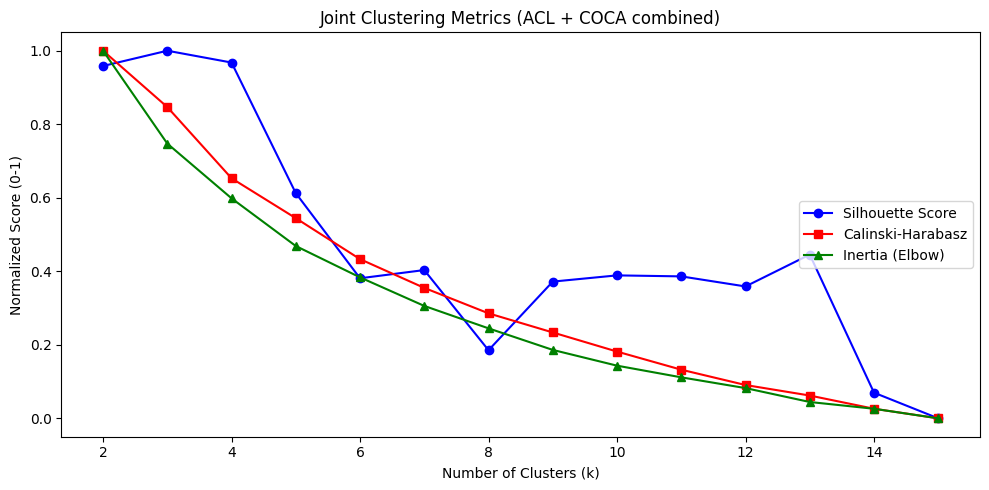


Joint Clustering:
  Silhouette: Best k = 3, Score = 0.0849
  Calinski-Harabasz: Best k = 2, Score = 487.90


In [82]:
# Plot clustering metrics for joint data
fig, ax = plt.subplots(figsize=(10, 5))

k_values_joint = list(k_range)
ax.plot(k_values_joint, normalize(sil_joint), 'b-o', label='Silhouette Score')
ax.plot(k_values_joint, normalize(ch_joint), 'r-s', label='Calinski-Harabasz')
ax.plot(k_values_joint, normalize(inertia_joint), 'g-^', label='Inertia (Elbow)')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Normalized Score (0-1)')
ax.set_title('Joint Clustering Metrics (ACL + COCA combined)')
ax.legend(loc='center right')

plt.tight_layout()
plt.show()

# Report best k for each metric
best_k_sil_joint = k_values_joint[np.argmax(sil_joint)]
best_k_ch_joint = k_values_joint[np.argmax(ch_joint)]

print(f"\nJoint Clustering:")
print(f"  Silhouette: Best k = {best_k_sil_joint}, Score = {max(sil_joint):.4f}")
print(f"  Calinski-Harabasz: Best k = {best_k_ch_joint}, Score = {max(ch_joint):.2f}")

In [83]:
# Run joint k-means for different k values and track source ratios per cluster
k_range = range(2, 16)
cluster_ratios = {}  # k -> list of (cluster_id, acl_ratio, coca_ratio, cluster_size)

# Also track clustering metrics
sil_joint = []
ch_joint = []
inertia_joint = []

for k in tqdm(k_range, desc="Joint clustering"):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_all)
    
    # Clustering metrics
    sil_joint.append(silhouette_score(X_all, labels))
    ch_joint.append(calinski_harabasz_score(X_all, labels))
    inertia_joint.append(kmeans.inertia_)
    
    ratios = []
    for cluster_id in range(k):
        mask = labels == cluster_id
        cluster_size = mask.sum()
        acl_count = ((sources == 'acl') & mask).sum()
        coca_count = ((sources == 'coca') & mask).sum()
        acl_ratio = acl_count / cluster_size if cluster_size > 0 else 0
        coca_ratio = coca_count / cluster_size if cluster_size > 0 else 0
        ratios.append((cluster_id, acl_ratio, coca_ratio, cluster_size))
    
    cluster_ratios[k] = ratios

Joint clustering: 100%|██████████| 14/14 [01:04<00:00,  4.58s/it]


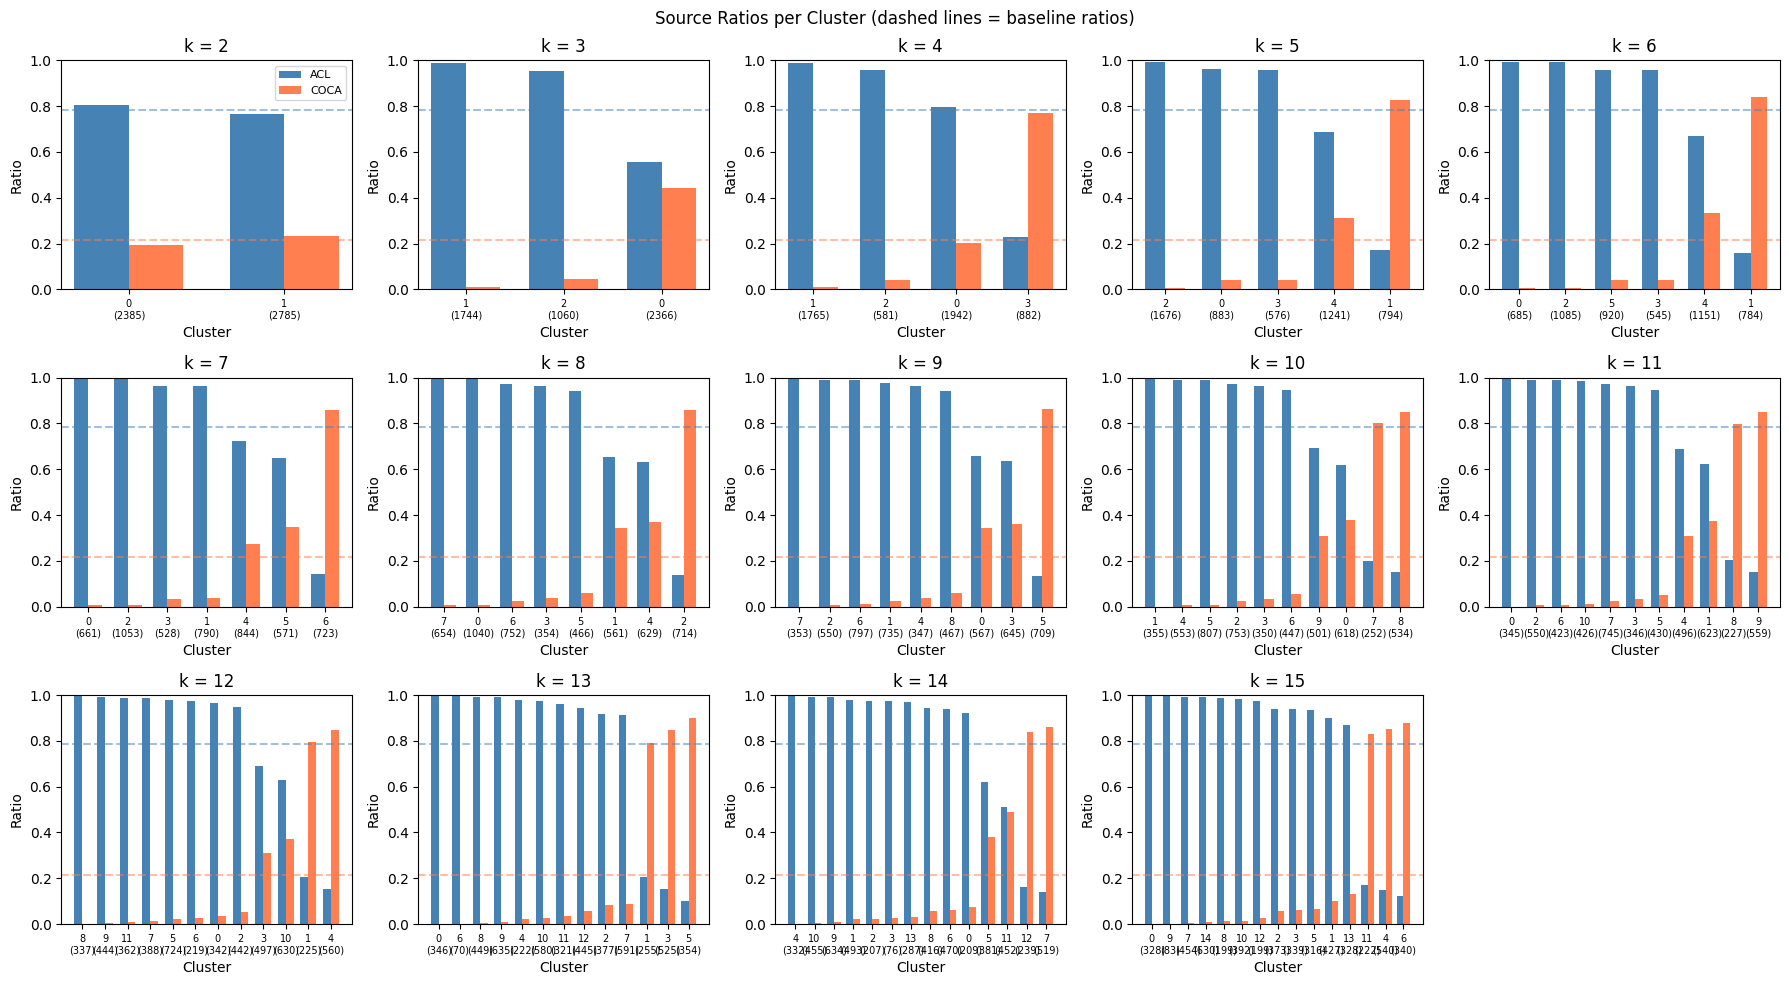

In [84]:
# Visualize source ratios per cluster as k increases
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

baseline_acl = (sources == 'acl').sum() / len(sources)

for i, k in enumerate(k_range):
    ax = axes[i]
    ratios = cluster_ratios[k]
    
    # Sort by ACL ratio for consistent visualization
    ratios_sorted = sorted(ratios, key=lambda x: x[1], reverse=True)
    
    cluster_ids = [r[0] for r in ratios_sorted]
    acl_ratios = [r[1] for r in ratios_sorted]
    coca_ratios = [r[2] for r in ratios_sorted]
    sizes = [r[3] for r in ratios_sorted]
    
    x = np.arange(k)
    width = 0.35
    
    ax.bar(x - width/2, acl_ratios, width, label='ACL', color='steelblue')
    ax.bar(x + width/2, coca_ratios, width, label='COCA', color='coral')
    ax.axhline(y=baseline_acl, color='steelblue', linestyle='--', alpha=0.5)
    ax.axhline(y=1-baseline_acl, color='coral', linestyle='--', alpha=0.5)
    
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Ratio')
    ax.set_title(f'k = {k}')
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{c}\n({s})' for c, s in zip(cluster_ids, sizes)], fontsize=7)
    
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)

# Hide empty subplots
for j in range(len(k_range), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Source Ratios per Cluster (dashed lines = baseline ratios)', fontsize=12)
plt.tight_layout()
plt.show()

As we increase the number of clusters, we get two overlapping senses (usage types with many tokens from each source). We never get a third strongly overlapping cluster. There are two from k=7 to k=12 and then they dissappearm but reappear again at k=14. This reappearance also corresponds with a jump in sillhouette score.

k=9 is chosen as the best overall K because it maintains the one distinct sense for COCA, the two overlapping senses. Increasing K just makes more granular divisions because of the continuous nature of vector representations and gradations in relation between polysemes. (Perhaps more granularity is warranted later, but we want as little as we can get away with.)

The clusters that overlap at k=9 are 0 and 3. 

### 5.1 Sample sentences from clusters


In [85]:
# Fit final joint k-means model with chosen k=9
best_k_joint = 9
kmeans_joint = KMeans(n_clusters=best_k_joint, random_state=42, n_init=10)
df['joint_cluster'] = kmeans_joint.fit_predict(X_all)

# Sample sentences from joint clusters
def sample_sentences_from_clusters(df, n_samples=5):
    """Sample sentences from each cluster in the dataframe."""
    sampled = {}
    for cluster_id in sorted(df['joint_cluster'].unique()):
        cluster_df = df[df['joint_cluster'] == cluster_id]
        samples = cluster_df.sample(n=min(n_samples, len(cluster_df)), random_state=42)
        sampled[cluster_id] = list(zip(
            samples['source'].tolist(),
            samples['sentence'].tolist()
        ))
    return sampled

# Sample from joint clusters
joint_samples = sample_sentences_from_clusters(df, n_samples=5)
print(f"Sampled sentences from joint clusters (k={best_k_joint}):\n")
for cluster_id, samples in joint_samples.items():
    # Count sources in this cluster
    cluster_df = df[df['joint_cluster'] == cluster_id]
    acl_count = (cluster_df['source'] == 'acl').sum()
    coca_count = (cluster_df['source'] == 'coca').sum()
    print(f"\nCluster {cluster_id} (ACL: {acl_count}, COCA: {coca_count}):")
    for source, sent in samples:
        print(f"  [{source.upper()}] {sent[:150]}...")

Sampled sentences from joint clusters (k=9):


Cluster 0 (ACL: 372, COCA: 195):
  [COCA] That 's a primary takeaway of the research on poverty : part of what makes poverty toxic may be the lack of control over what 's happening to you . #...
  [COCA] @!KIRSTEN-GILLIBRAND# And you just heard from these victims , there are too many command climates that are toxic ....
  [ACL] Online abuse can inflict harm on users and communities, making online spaces unsafe and toxic....
  [COCA] And it truly is , you know , it 's ... @!MIKE-MYERS# It 's a toxic - I would say it 's the industrial disease of creativity ....
  [COCA] The moves this past week may not simplify Matheny 's call but so far it 's turned parts of the bullpen from toxic to electric ....

Cluster 1 (ACL: 717, COCA: 18):
  [ACL] The main contributions of this work are the following: • We addressed for the second time the task of unsupervised civil rephrases of toxic texts, rel...
  [ACL] Figure 3 shows the most frequent toxic spans

Analysis:

The overlapping clusters are 0 and 3
These are both metaphorical . Cluster 0 focuses on the toxic situation or environment. Cluster 3 focuses on the toxic person or agent, as well as the toxic substance (toxic content)

In [86]:
# Summary: How many clusters are dominated by each source as k increases?
print("Cluster dominance summary (>60% from one source):\n")
print(f"{'k':<5} {'ACL-dominated':<15} {'COCA-dominated':<15} {'Mixed':<10}")
print("-" * 45)

for k in k_range:
    ratios = cluster_ratios[k]
    acl_dom = sum(1 for r in ratios if r[1] > 0.6)
    coca_dom = sum(1 for r in ratios if r[2] > 0.6)
    mixed = k - acl_dom - coca_dom
    print(f"{k:<5} {acl_dom:<15} {coca_dom:<15} {mixed:<10}")

Cluster dominance summary (>60% from one source):

k     ACL-dominated   COCA-dominated  Mixed     
---------------------------------------------
2     2               0               0         
3     2               0               1         
4     3               1               0         
5     4               1               0         
6     5               1               0         
7     6               1               0         
8     7               1               0         
9     8               1               0         
10    8               2               0         
11    9               2               0         
12    10              2               0         
13    10              3               0         
14    11              2               1         
15    12              3               0         


Cluster dominance results show that there is one specific subsense / usage in COCA that is not common in ACL. No more COCA-dominated clusters emerge until we get very granular (K=11). This makes sense because ACL is the more general corpus, and we would expect ACL would have more specific uses that don't appear in COCA, whereas COCA has more common senses/usage types that are likely to appear in ACL. 

## 6. UMAP Visualization

Visualize the clusters using UMAP dimensionality reduction. Color indicates the data source (ACL vs COCA), shape indicates the cluster assignment.

In [87]:
# Combine embeddings and cluster labels from both sources
# Add cluster labels to dataframes
df_acl['cluster'] = acl_labels
df_coca['cluster'] = coca_labels

# Combine into single dataframe for visualization
df_viz = pd.concat([df_acl, df_coca], ignore_index=True)

# Stack embeddings
X_viz = np.stack(df_viz['embedding'].values)

print(f"Combined data shape: {X_viz.shape}")
print(f"ACL samples: {len(df_acl)}, COCA samples: {len(df_coca)}")

Combined data shape: (5170, 768)
ACL samples: 4056, COCA samples: 1114


In [88]:
# Run UMAP on the combined embeddings
print("Running UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_viz)

df_viz['umap_x'] = X_umap[:, 0]
df_viz['umap_y'] = X_umap[:, 1]

print(f"UMAP complete! Shape: {X_umap.shape}")

Running UMAP...


/home/gsc685/miniconda3/envs/pedersen_validation/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP complete! Shape: (5170, 2)


In [89]:
# Interactive visualization with Plotly
# Color = source, Shape = cluster, Hover = sentence

# Prepare hover text (wrap sentences for readability)
df_viz['hover_text'] = df_viz['sentence'].apply(lambda x: '<br>'.join([x[i:i+80] for i in range(0, len(x), 80)]))

# Define colors for sources and symbols for clusters
source_colors = {'acl': 'steelblue', 'coca': 'coral'}
cluster_symbols = ['circle', 'square', 'diamond', 'cross', 'x', 'triangle-up', 'triangle-down', 'star', 'hexagon', 'pentagon']

fig = go.Figure()

# Plot each source-cluster combination
for source in ['acl', 'coca']:
    for cluster in range(best_k):
        mask = (df_viz['source'] == source) & (df_viz['cluster'] == cluster)
        subset = df_viz[mask]
        
        fig.add_trace(go.Scatter(
            x=subset['umap_x'],
            y=subset['umap_y'],
            mode='markers',
            marker=dict(
                size=8,
                color=source_colors[source],
                symbol=cluster_symbols[cluster % len(cluster_symbols)],
                opacity=0.6
            ),
            name=f'{source.upper()} - Cluster {cluster}',
            hovertext=subset['hover_text'],
            hoverinfo='text'
        ))

fig.update_layout(
    title=f'UMAP Visualization of "toxic" Embeddings (Color = Source, Shape = Cluster, k={best_k})',
    xaxis_title='UMAP Dimension 1',
    yaxis_title='UMAP Dimension 2',
    width=1000,
    height=800,
    hovermode='closest',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02
    )
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

In [90]:
# Alternative view: Side-by-side interactive plots for ACL and COCA separately
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=2, subplot_titles=('ACL Clusters', 'COCA Clusters'))

colors = px.colors.qualitative.T10

for col, source in enumerate(['acl', 'coca'], start=1):
    source_mask = df_viz['source'] == source
    subset = df_viz[source_mask]
    
    for cluster in range(best_k):
        cluster_mask = subset['cluster'] == cluster
        cluster_subset = subset[cluster_mask]
        
        fig.add_trace(go.Scatter(
            x=cluster_subset['umap_x'],
            y=cluster_subset['umap_y'],
            mode='markers',
            marker=dict(
                size=8,
                color=colors[cluster % len(colors)],
                opacity=0.6
            ),
            name=f'Cluster {cluster}',
            hovertext=cluster_subset['hover_text'],
            hoverinfo='text',
            legendgroup=f'cluster_{cluster}',
            showlegend=(col == 1)  # Only show legend for first subplot
        ), row=1, col=col)

fig.update_layout(
    title=f'UMAP Visualization by Source (k={best_k})',
    width=1400,
    height=700,
    hovermode='closest'
)

fig.show()

## 7. Save Cluster Assignments

Save a dataframe with token_id, cluster (from source-specific k-means), and joint_cluster.

In [91]:
# Create source_cluster column by mapping from df_acl and df_coca
acl_cluster_map = dict(zip(df_acl.index, df_acl['cluster']))
coca_cluster_map = dict(zip(df_coca.index, df_coca['cluster']))
df['source_cluster'] = df.index.map({**acl_cluster_map, **coca_cluster_map})

# Save dataframe with selected columns
output_df = df[['token_id', 'source', 'source_cluster', 'joint_cluster', 'embedding']].copy()
output_df['source_cluster'] = output_df['source_cluster'].astype(int)
output_df['joint_cluster'] = output_df['joint_cluster'].astype(int)

output_path = '/home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_cluster_assignments.csv'
output_df.to_csv(output_path, index=False)

print(f"Saved cluster assignments to: {output_path}")
print(f"Shape: {output_df.shape}")
print(f"\nPreview:")
output_df.head(10)

Saved cluster assignments to: /home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_cluster_assignments.csv
Shape: (5170, 5)

Preview:


,token_id,source,source_cluster,joint_cluster,embedding
0,0,acl,2,5,"[0.18830034, -0.0065299724, 0.087106325, -0.67..."
1,1,acl,1,3,"[0.33407915, 0.2139748, -0.2950357, -0.7871766..."
2,2,acl,1,1,"[0.24179465, 0.25775725, -0.17181094, -0.37775..."
3,3,acl,7,5,"[-0.18737654, 0.17003542, -0.23744693, -0.3237..."
4,4,acl,5,2,"[0.034304023, -0.0695125, 0.15187693, -0.68974..."
5,5,acl,2,7,"[-0.19667678, 0.47995102, -0.03136545, -0.7859..."
6,6,acl,2,7,"[-0.19667678, 0.47995102, -0.03136545, -0.7859..."
7,11,acl,2,7,"[0.3075167, 0.25756538, 0.32159203, -0.4395444..."
8,12,acl,2,7,"[0.3075167, 0.25756538, 0.32159203, -0.4395444..."
9,13,acl,0,6,"[-0.11838372, 0.20425321, -0.11597952, -0.4013..."
